# X-Ray Bone Boundary Detection Using Convolution

## Deep Learning Essentials – Innovative Assignment

### Topic: Convolution Operation

**Problem Statement:**  
An X-ray processing system uses an edge-detection kernel to emphasize bone boundaries. Apply the kernel to the supplied image patch, calculate the resulting responses, and demonstrate which locations are emphasized.

### Objective

The objective of this experiment is to demonstrate how a convolution operation can detect intensity changes corresponding to potential bone boundaries in an X-ray image.

### Steps

1. Load the X-ray image.
2. Convert the image to grayscale.
3. Select a small image patch.
4. Define an edge-detection kernel.
5. Apply convolution.
6. Calculate the response matrix.
7. Identify strong edge responses.
8. Visualize the emphasized locations.

Import libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

Check the dataset

In [2]:
image_path = "../dataset/xray_original.png"

if os.path.exists(image_path):
    print("X-ray image found successfully.")
    print("Path:", image_path)
else:
    print("ERROR: X-ray image was not found.")
    print("Please check that the image is located at:")
    print("dataset/xray_original.png")

X-ray image found successfully.
Path: ../dataset/xray_original.png


Load the X-ray

In [3]:
image = Image.open(image_path).convert("L")

image_array = np.array(
    image,
    dtype=float
)

print("X-ray loaded successfully.")
print("Image dimensions:", image_array.shape)
print("Minimum pixel value:", image_array.min())
print("Maximum pixel value:", image_array.max())

X-ray loaded successfully.
Image dimensions: (610, 402)
Minimum pixel value: 0.0
Maximum pixel value: 188.0


Display the original X-ray

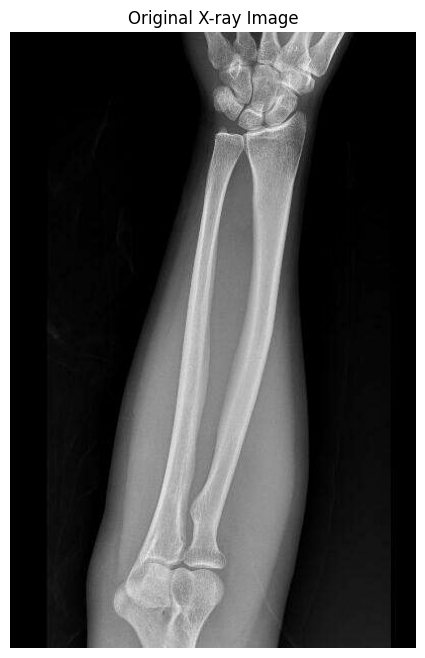

In [4]:
plt.figure(figsize=(8, 8))

plt.imshow(
    image_array,
    cmap="gray"
)

plt.title("Original X-ray Image")
plt.axis("off")

plt.show()

Save the X-ray result

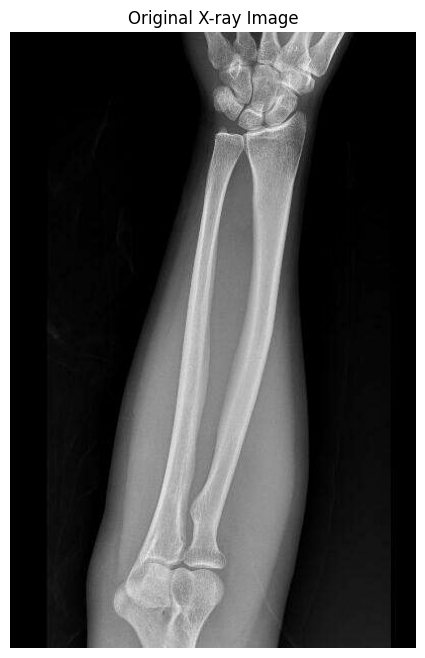

Saved: results/input_xray.png


In [5]:
os.makedirs("../results", exist_ok=True)

plt.figure(figsize=(8, 8))

plt.imshow(
    image_array,
    cmap="gray"
)

plt.title("Original X-ray Image")
plt.axis("off")

plt.savefig(
    "../results/input_xray.png",
    bbox_inches="tight"
)

plt.show()

print("Saved: results/input_xray.png")

Select the image patch

In [6]:
# Temporary coordinates.
# These can be changed after inspecting the X-ray.

x = 100
y = 100

patch_width = 15
patch_height = 15

patch = image_array[
    y:y + patch_height,
    x:x + patch_width
]

print("Patch dimensions:", patch.shape)

Patch dimensions: (15, 15)


Display the selected patch

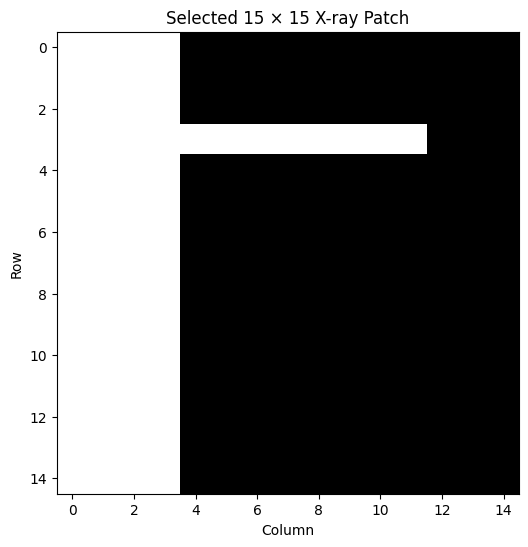

In [7]:
plt.figure(figsize=(6, 6))

plt.imshow(
    patch,
    cmap="gray"
)

plt.title("Selected 15 × 15 X-ray Patch")
plt.xlabel("Column")
plt.ylabel("Row")

plt.show()

Print the pixel matrix

In [8]:
np.set_printoptions(
    precision=0,
    suppress=True
)

print("15 × 15 Pixel Matrix:")
print(patch)

15 × 15 Pixel Matrix:
[[1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


Visualize pixel values

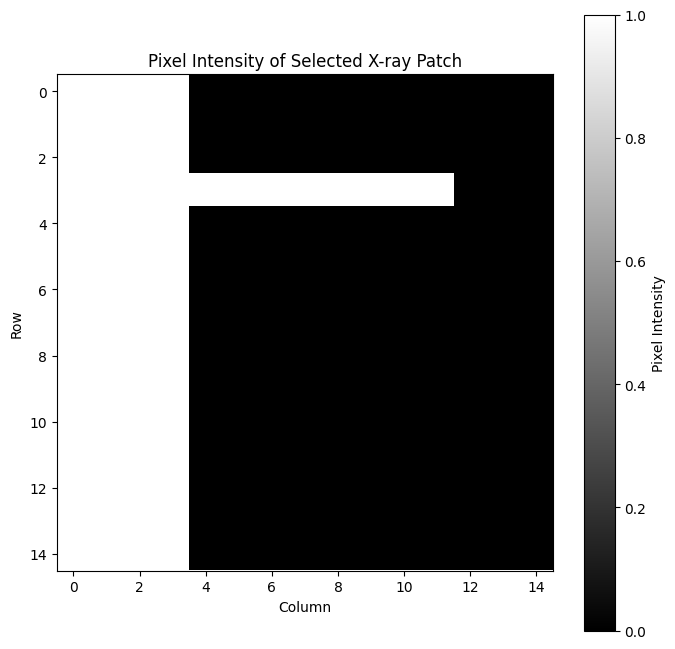

In [9]:
plt.figure(figsize=(8, 8))

plt.imshow(
    patch,
    cmap="gray"
)

plt.colorbar(
    label="Pixel Intensity"
)

plt.title(
    "Pixel Intensity of Selected X-ray Patch"
)

plt.xlabel("Column")
plt.ylabel("Row")

plt.show()

Define the edge-detection kernel

In [10]:
kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=float)

print("3 × 3 Edge Detection Kernel:")
print(kernel)

3 × 3 Edge Detection Kernel:
[[-1. -1. -1.]
 [-1.  8. -1.]
 [-1. -1. -1.]]


## Edge Detection Kernel

The following 3 × 3 Laplacian-style kernel is used:

\[
K =
\begin{bmatrix}
-1 & -1 & -1 \\
-1 & 8 & -1 \\
-1 & -1 & -1
\end{bmatrix}
\]

The central pixel is multiplied by 8, while the surrounding pixels are multiplied by -1.

The kernel produces a large response when the center pixel has a significantly different intensity from its surrounding pixels. Therefore, strong responses indicate possible edges or boundaries.

## Convolution Calculation

For every location, the kernel is placed over a 3 × 3 region of the image.

The response is calculated using:

\[
R(i,j) =
\sum_m \sum_n I(i+m,j+n)K(m,n)
\]

where:

- \(I\) = image pixel values
- \(K\) = edge-detection kernel
- \(R(i,j)\) = convolution response

For a 15 × 15 patch using a 3 × 3 kernel with stride 1 and no padding:

\[
O = \frac{N-F+2P}{S}+1
\]

\[
O = \frac{15-3+0}{1}+1
\]

\[
O = 13
\]

Therefore, the convolution produces a:

\[
\boxed{13\times13}
\]

response matrix.

In [11]:
def convolution(image, kernel):

    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    output_height = (
        image_height - kernel_height + 1
    )

    output_width = (
        image_width - kernel_width + 1
    )

    output = np.zeros(
        (
            output_height,
            output_width
        )
    )

    for i in range(output_height):

        for j in range(output_width):

            region = image[
                i:i + kernel_height,
                j:j + kernel_width
            ]

            response = np.sum(
                region * kernel
            )

            output[i, j] = response

    return output

In [12]:
response = convolution(
    patch,
    kernel
)

print("Input patch shape:", patch.shape)
print("Kernel shape:", kernel.shape)
print("Response shape:", response.shape)

Input patch shape: (15, 15)
Kernel shape: (3, 3)
Response shape: (13, 13)


In [13]:
np.set_printoptions(
    precision=2,
    suppress=True
)

print("13 × 13 Convolution Response Matrix:")
print(response)

13 × 13 Convolution Response Matrix:
[[ 0.  0.  3. -3.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  2. -5. -3. -3. -3. -3. -3. -3. -2. -1.  0.]
 [ 0.  0.  2.  4.  6.  6.  6.  6.  6.  6.  7. -1.  0.]
 [ 0.  0.  2. -5. -3. -3. -3. -3. -3. -3. -2. -1.  0.]
 [ 0.  0.  3. -3.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  3. -3.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  3. -3.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  3. -3.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  3. -3.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  3. -3.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  3. -3.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  3. -3.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  3. -3.  0.  0.  0.  0.  0.  0.  0.  0.  0.]]


In [15]:
region = patch[0:3, 0:3]

first_response = np.sum(
    region * kernel
)

print("First 3 × 3 image region:")
print(region)

print("\nKernel:")
print(kernel)

print(
    "\nFirst convolution response:",
    first_response
)

print(
    "Response from convolution matrix:",
    response[0, 0]
)

First 3 × 3 image region:
[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]

Kernel:
[[-1. -1. -1.]
 [-1.  8. -1.]
 [-1. -1. -1.]]

First convolution response: 0.0
Response from convolution matrix: 0.0


In [16]:
magnitude = np.abs(response)

max_value = magnitude.max()

max_location = np.unravel_index(
    np.argmax(magnitude),
    magnitude.shape
)

print(
    "Maximum response magnitude:",
    max_value
)

print(
    "Strongest response location:",
    max_location
)

print(
    "Signed response at this location:",
    response[max_location]
)

Maximum response magnitude: 7.0
Strongest response location: (np.int64(2), np.int64(10))
Signed response at this location: 7.0


In [17]:
mean_response = magnitude.mean()
std_response = magnitude.std()

threshold = (
    mean_response
    + std_response
)

print("Mean response magnitude:", mean_response)
print("Standard deviation:", std_response)
print("Edge threshold:", threshold)

Mean response magnitude: 0.9822485207100592
Standard deviation: 1.683450151210376
Edge threshold: 2.665698671920435


In [18]:
emphasized_locations = np.argwhere(
    magnitude >= threshold
)

print(
    "Number of emphasized locations:",
    len(emphasized_locations)
)

print("\nEmphasized locations:")

for row, column in emphasized_locations:

    print(
        f"({row}, {column}) -> "
        f"Response = "
        f"{response[row, column]:.2f}, "
        f"Magnitude = "
        f"{magnitude[row, column]:.2f}"
    )

Number of emphasized locations: 42

Emphasized locations:
(0, 2) -> Response = 3.00, Magnitude = 3.00
(0, 3) -> Response = -3.00, Magnitude = 3.00
(1, 3) -> Response = -5.00, Magnitude = 5.00
(1, 4) -> Response = -3.00, Magnitude = 3.00
(1, 5) -> Response = -3.00, Magnitude = 3.00
(1, 6) -> Response = -3.00, Magnitude = 3.00
(1, 7) -> Response = -3.00, Magnitude = 3.00
(1, 8) -> Response = -3.00, Magnitude = 3.00
(1, 9) -> Response = -3.00, Magnitude = 3.00
(2, 3) -> Response = 4.00, Magnitude = 4.00
(2, 4) -> Response = 6.00, Magnitude = 6.00
(2, 5) -> Response = 6.00, Magnitude = 6.00
(2, 6) -> Response = 6.00, Magnitude = 6.00
(2, 7) -> Response = 6.00, Magnitude = 6.00
(2, 8) -> Response = 6.00, Magnitude = 6.00
(2, 9) -> Response = 6.00, Magnitude = 6.00
(2, 10) -> Response = 7.00, Magnitude = 7.00
(3, 3) -> Response = -5.00, Magnitude = 5.00
(3, 4) -> Response = -3.00, Magnitude = 3.00
(3, 5) -> Response = -3.00, Magnitude = 3.00
(3, 6) -> Response = -3.00, Magnitude = 3.00
(3, 7

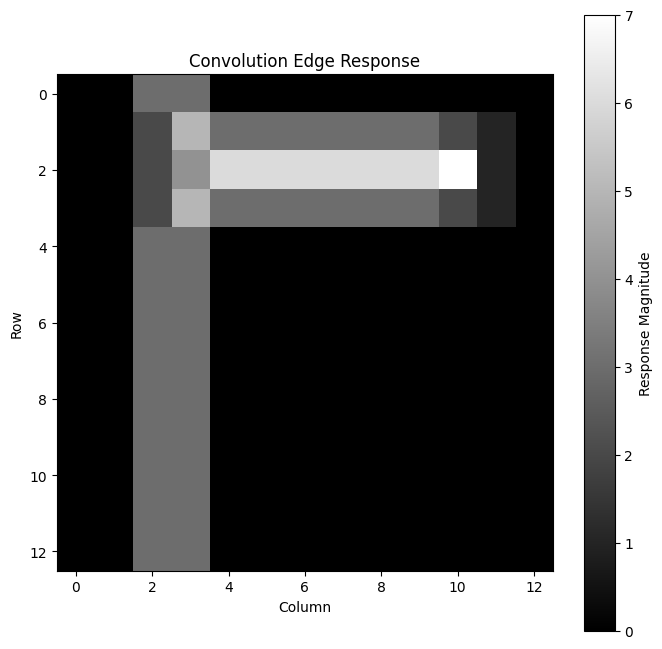

In [19]:
plt.figure(figsize=(8, 8))

plt.imshow(
    magnitude,
    cmap="gray"
)

plt.colorbar(
    label="Response Magnitude"
)

plt.title(
    "Convolution Edge Response"
)

plt.xlabel("Column")
plt.ylabel("Row")

plt.show()

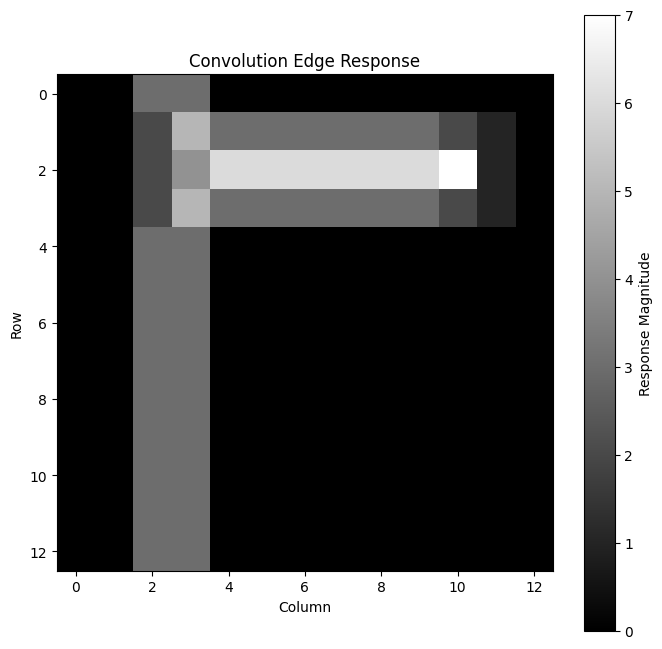

Saved: results/edge_response.png


In [20]:
plt.figure(figsize=(8, 8))

plt.imshow(
    magnitude,
    cmap="gray"
)

plt.colorbar(
    label="Response Magnitude"
)

plt.title(
    "Convolution Edge Response"
)

plt.xlabel("Column")
plt.ylabel("Row")

plt.savefig(
    "../results/edge_response.png",
    bbox_inches="tight"
)

plt.show()

print("Saved: results/edge_response.png")

In [21]:
edge_map = (
    magnitude >= threshold
)

print(
    "Edge map shape:",
    edge_map.shape
)

Edge map shape: (13, 13)


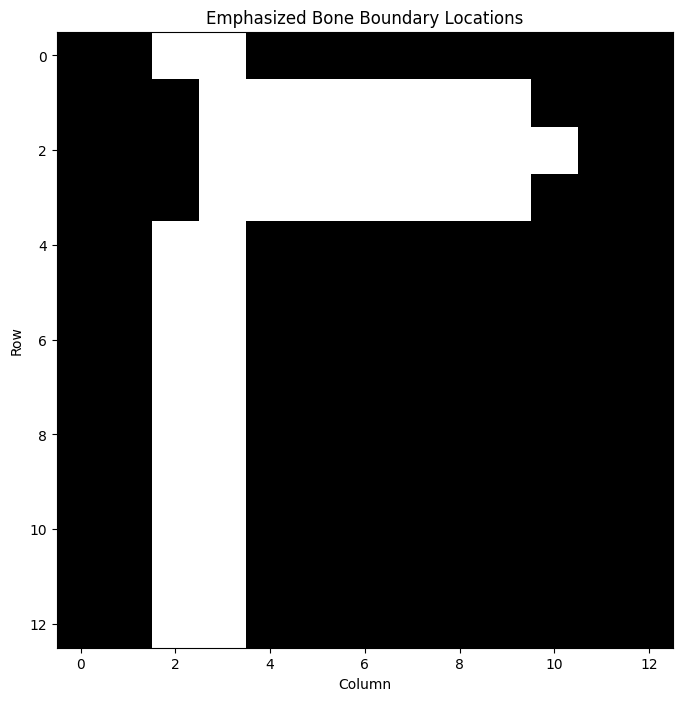

In [22]:
plt.figure(figsize=(8, 8))

plt.imshow(
    edge_map,
    cmap="gray"
)

plt.title(
    "Emphasized Bone Boundary Locations"
)

plt.xlabel("Column")
plt.ylabel("Row")

plt.show()

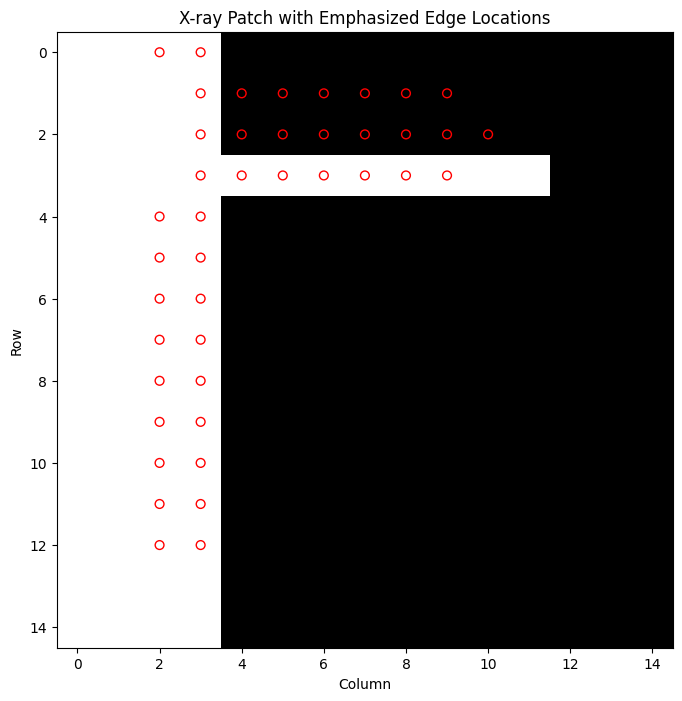

In [23]:
plt.figure(figsize=(8, 8))

plt.imshow(
    patch,
    cmap="gray"
)

rows, columns = np.where(
    edge_map
)

plt.scatter(
    columns,
    rows,
    s=40,
    facecolors="none",
    edgecolors="red"
)

plt.title(
    "X-ray Patch with Emphasized Edge Locations"
)

plt.xlabel("Column")
plt.ylabel("Row")

plt.show()

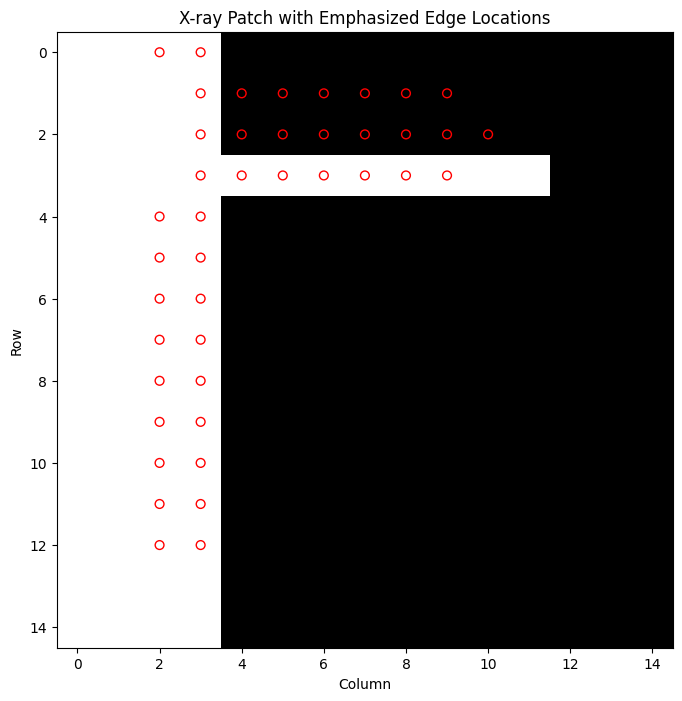

Saved: results/emphasized_edges.png


In [24]:
plt.figure(figsize=(8, 8))

plt.imshow(
    patch,
    cmap="gray"
)

rows, columns = np.where(
    edge_map
)

plt.scatter(
    columns,
    rows,
    s=40,
    facecolors="none",
    edgecolors="red"
)

plt.title(
    "X-ray Patch with Emphasized Edge Locations"
)

plt.xlabel("Column")
plt.ylabel("Row")

plt.savefig(
    "../results/emphasized_edges.png",
    bbox_inches="tight"
)

plt.show()

print(
    "Saved: results/emphasized_edges.png"
)

In [25]:
response_dataframe = pd.DataFrame(
    response
)

response_dataframe.to_csv(
    "../results/response_matrix.csv",
    index=False,
    header=False
)

print(
    "Saved: results/response_matrix.csv"
)

Saved: results/response_matrix.csv


# Results and Discussion

## Input

A grayscale X-ray image was used as the input. A 15 × 15 pixel region containing a representative bone area was selected for convolution analysis.

## Kernel

A 3 × 3 Laplacian-style edge-detection kernel was applied:

\[
\begin{bmatrix}
-1 & -1 & -1 \\
-1 & 8 & -1 \\
-1 & -1 & -1
\end{bmatrix}
\]

## Convolution Output

With a 15 × 15 input patch, 3 × 3 kernel, stride 1, and no padding, the resulting output is:

\[
13 \times 13
\]

The response matrix contains the calculated convolution value at every valid kernel position.

## Interpretation

Large absolute response values indicate strong local intensity changes. Such locations are emphasized because the intensity of the central pixel differs significantly from its neighboring pixels.

These strong responses can correspond to visible bone boundaries or other sharp intensity transitions in the X-ray.

## Strongest Response

The location having the largest response magnitude represents the strongest detected edge within the selected patch.

## Conclusion

The experiment demonstrates the basic convolution operation used in deep learning image processing. The edge-detection kernel successfully produces strong responses at locations with significant intensity changes, allowing potential bone boundaries to be emphasized.